#  Forest Cover Type Classification using Decision Trees

## Project Overview

This project explores the use of **Decision Tree Classifiers** to predict forest cover types from cartographic variables.

The notebook follows the concepts introduced in **Chapter 6 – Decision Trees** from *Hands-On Machine Learning* by Aurélien Géron.

The objectives of this project are to:

- Build a baseline Decision Tree model.
- Understand overfitting in Decision Trees.
- Tune hyperparameters using GridSearchCV.
- Interpret feature importance.
- Compare Decision Trees with Random Forests.

#  Dataset

The **Forest Cover Type** dataset contains cartographic variables describing forest areas in the Roosevelt National Forest, Colorado.

Each observation belongs to one of **seven forest cover types**.

This is a multiclass classification problem where the goal is to predict the correct forest cover type based on environmental measurements.

In [50]:
import pandas as pd
train_df = pd.read_csv("/kaggle/input/competitions/forest-cover-type-prediction/train.csv")
test_df = pd.read_csv("/kaggle/input/competitions/forest-cover-type-prediction/test.csv")
train_df.shape, test_df.shape

((15120, 56), (565892, 55))

#  Initial Data Inspection

Before building a machine learning model, we first inspect the dataset to understand:

- Number of samples
- Number of features
- Data types
- Missing values
- Overall structure

In [51]:
train_df.head()

,Id,Elevation,Aspect,Slope,Horizontal_Distance_To_Hydrology,Vertical_Distance_To_Hydrology,Horizontal_Distance_To_Roadways,Hillshade_9am,Hillshade_Noon,Hillshade_3pm,...,Soil_Type32,Soil_Type33,Soil_Type34,Soil_Type35,Soil_Type36,Soil_Type37,Soil_Type38,Soil_Type39,Soil_Type40,Cover_Type
0,1,2596,51,3,258,0,510,221,232,148,...,0,0,0,0,0,0,0,0,0,5
1,2,2590,56,2,212,-6,390,220,235,151,...,0,0,0,0,0,0,0,0,0,5
2,3,2804,139,9,268,65,3180,234,238,135,...,0,0,0,0,0,0,0,0,0,2
3,4,2785,155,18,242,118,3090,238,238,122,...,0,0,0,0,0,0,0,0,0,2
4,5,2595,45,2,153,-1,391,220,234,150,...,0,0,0,0,0,0,0,0,0,5


In [52]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15120 entries, 0 to 15119
Data columns (total 56 columns):
 #   Column                              Non-Null Count  Dtype
---  ------                              --------------  -----
 0   Id                                  15120 non-null  int64
 1   Elevation                           15120 non-null  int64
 2   Aspect                              15120 non-null  int64
 3   Slope                               15120 non-null  int64
 4   Horizontal_Distance_To_Hydrology    15120 non-null  int64
 5   Vertical_Distance_To_Hydrology      15120 non-null  int64
 6   Horizontal_Distance_To_Roadways     15120 non-null  int64
 7   Hillshade_9am                       15120 non-null  int64
 8   Hillshade_Noon                      15120 non-null  int64
 9   Hillshade_3pm                       15120 non-null  int64
 10  Horizontal_Distance_To_Fire_Points  15120 non-null  int64
 11  Wilderness_Area1                    15120 non-null  int64
 12  Wild

#  Feature Preparation

The **Id** column is removed since it contains no predictive information.

The target variable (**Cover_Type**) is separated from the feature matrix.

In [53]:
X = train_df.drop(["Id","Cover_Type"],axis=1)
y = train_df["Cover_Type"]

X_test = test_df.drop("Id",axis=1)

In [54]:
from sklearn.model_selection import train_test_split
X_train,X_valid,y_train,y_valid = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [55]:
X_train.shape,X_valid.shape

((12096, 54), (3024, 54))

#  Baseline Decision Tree

We begin by training a Decision Tree using its default hyperparameters.

This baseline serves as a reference point before applying any optimization techniques.

In [56]:
from sklearn.tree import DecisionTreeClassifier
tree_clf = DecisionTreeClassifier(random_state=42)
tree_clf.fit(X_train,y_train)

DecisionTreeClassifier(random_state=42)

In [57]:
pred = tree_clf.predict(X_valid)

#  Model Evaluation

The baseline model is evaluated using:

- Accuracy
- Precision
- Recall
- F1-score
- Confusion Matrix

These metrics help assess how well the model performs across all seven forest cover classes.

In [58]:
from sklearn.metrics import accuracy_score
accuracy_score(y_valid,pred)

0.7903439153439153

In [59]:
default_cv = cross_val_score(
    tree_clf,
    X_train,
    y_train,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

print(default_cv)
print("Mean CV:", default_cv.mean())

[0.77066116 0.77594047 0.77966102 0.77139314 0.76560562]
Mean CV: 0.7726522810122345


In [60]:
from sklearn.metrics import classification_report
classification_report(y_valid,pred)

'              precision    recall  f1-score   support\n\n           1       0.69      0.65      0.67       432\n           2       0.62      0.62      0.62       432\n           3       0.72      0.75      0.73       432\n           4       0.93      0.92      0.92       432\n           5       0.86      0.89      0.88       432\n           6       0.78      0.78      0.78       432\n           7       0.92      0.92      0.92       432\n\n    accuracy                           0.79      3024\n   macro avg       0.79      0.79      0.79      3024\nweighted avg       0.79      0.79      0.79      3024\n'

#  Feature Importance

One advantage of Decision Trees is that they naturally estimate feature importance.

This allows us to identify which environmental variables contribute most to predicting forest cover type.

In [61]:
feature_importance = pd.Series(
    tree_clf.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

feature_importance

Elevation                             0.409003
Horizontal_Distance_To_Fire_Points    0.091559
Horizontal_Distance_To_Roadways       0.090119
Horizontal_Distance_To_Hydrology      0.066598
Hillshade_9am                         0.057937
Hillshade_Noon                        0.040459
Vertical_Distance_To_Hydrology        0.036812
Aspect                                0.034316
Hillshade_3pm                         0.027222
Slope                                 0.018931
Soil_Type4                            0.014596
Wilderness_Area1                      0.014271
Soil_Type3                            0.013842
Soil_Type10                           0.012047
Wilderness_Area3                      0.009398
Soil_Type39                           0.006651
Soil_Type32                           0.006229
Soil_Type38                           0.005299
Soil_Type12                           0.005133
Soil_Type6                            0.003167
Soil_Type17                           0.002990
Soil_Type35  

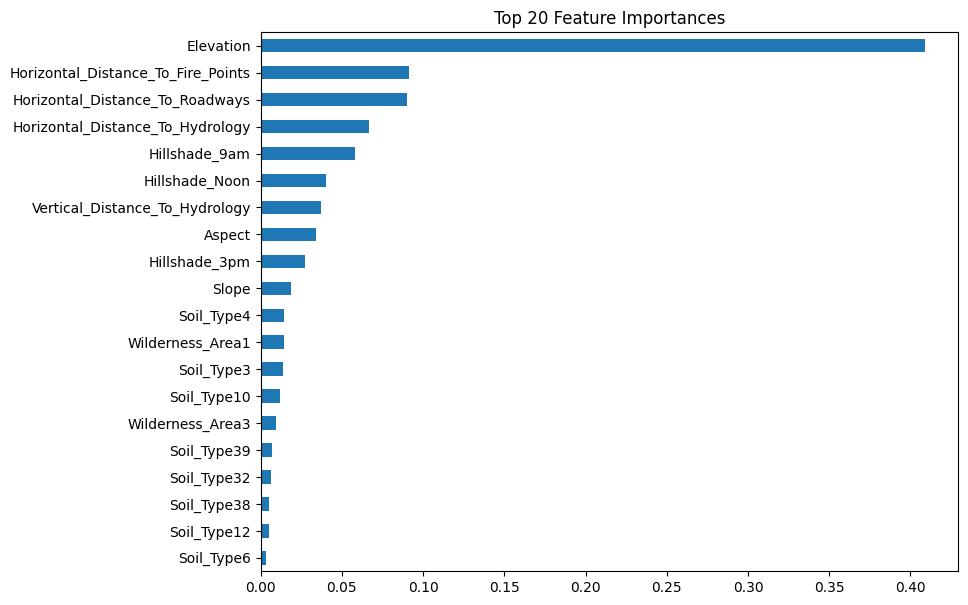

In [62]:
import matplotlib.pyplot as plt

plt.figure(figsize=(9,7))
feature_importance.head(20).sort_values().plot(kind="barh")
plt.title("Top 20 Feature Importances")
plt.show()

#  Visualizing the Decision Tree

Decision Trees are highly interpretable models.

Visualizing the upper levels of the tree helps us understand:

- Feature splits
- Decision boundaries
- Gini impurity
- Predicted classes

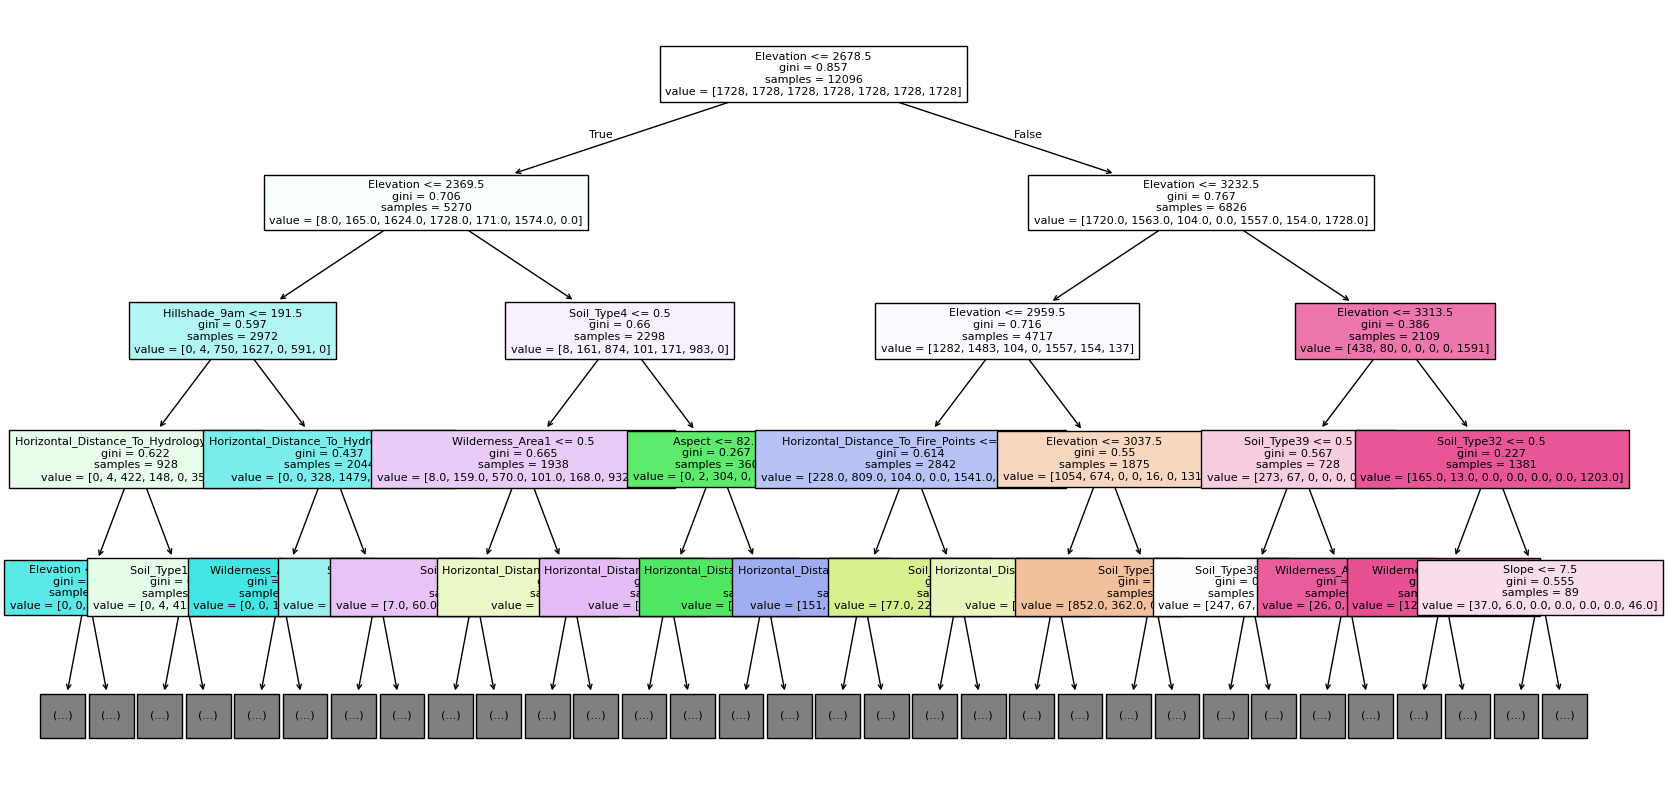

In [63]:
from sklearn.tree import plot_tree

plt.figure(figsize=(20,10))

plot_tree(
    tree_clf,
    max_depth=4,
    feature_names=X.columns,
    filled=True,
    fontsize=8
)

plt.show()

In [64]:
print("Training Accuracy:", tree_clf.score(X_train, y_train))
print("Validation Accuracy:", tree_clf.score(X_valid, y_valid))

Training Accuracy: 1.0
Validation Accuracy: 0.7903439153439153


#  Overfitting Analysis

Decision Trees can easily memorize the training data if allowed to grow without constraints.

To study this behavior, we train trees with different maximum depths and compare:

- Training Accuracy
- Validation Accuracy

This demonstrates the concepts of:

- Underfitting
- Good Generalization
- Overfitting

In [65]:
depths = range(2, 21)

train_scores = []
valid_scores = []

for depth in depths:

    clf = DecisionTreeClassifier(
        max_depth=depth,
        random_state=42
    )

    clf.fit(X_train, y_train)

    train_scores.append(clf.score(X_train, y_train))
    valid_scores.append(clf.score(X_valid, y_valid))

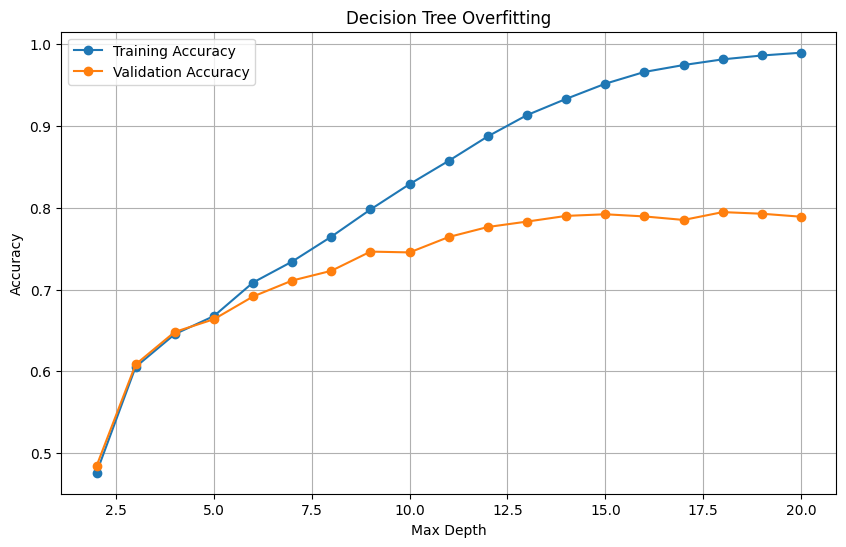

In [66]:
plt.figure(figsize=(10,6))

plt.plot(depths, train_scores, marker="o", label="Training Accuracy")

plt.plot(depths, valid_scores, marker="o", label="Validation Accuracy")

plt.xlabel("Max Depth")
plt.ylabel("Accuracy")
plt.title("Decision Tree Overfitting")

plt.legend()

plt.grid(True)

plt.show()

#  Hyperparameter Tuning

GridSearchCV is used to automatically search for the best combination of hyperparameters.

The following parameters are optimized:

- Criterion
- Maximum Depth
- Minimum Samples Split
- Minimum Samples Leaf

The objective is to improve generalization while reducing overfitting.

In [67]:
param_grid = {
    "criterion": ["gini", "entropy"],
    "max_depth": [12, 15, 18, 20],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4]
}

In [68]:
from sklearn.model_selection import GridSearchCV

grid_search = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

GridSearchCV(cv=5, estimator=DecisionTreeClassifier(random_state=42), n_jobs=-1,
             param_grid={'criterion': ['gini', 'entropy'],
                         'max_depth': [12, 15, 18, 20],
                         'min_samples_leaf': [1, 2, 4],
                         'min_samples_split': [2, 5, 10]},
             scoring='accuracy')

In [69]:
grid_search.best_params_,grid_search.best_score_

({'criterion': 'entropy',
  'max_depth': 18,
  'min_samples_leaf': 1,
  'min_samples_split': 2},
 np.float64(0.7783579718413797))

#  Tuned Decision Tree

Using the best hyperparameters obtained from GridSearchCV, we train a new Decision Tree and compare its performance with the baseline model.

In [70]:
best_tree = grid_search.best_estimator_

pred = best_tree.predict(X_valid)

print("Validation Accuracy:",accuracy_score(y_valid,pred))

Validation Accuracy: 0.7827380952380952


#  Cross Validation

Instead of relying on a single train-validation split, we evaluate the Decision Tree using **5-fold Cross Validation**.

This provides a more reliable estimate of the model's generalization performance.

In [71]:
from sklearn.model_selection import cross_val_score
tuned_cv = cross_val_score(
    best_tree,
    X_train,
    y_train,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)
print(tuned_cv)
print("Mean Accuracy:",tuned_cv.mean())

[0.76033058 0.7809012  0.79412981 0.78255477 0.7738735 ]
Mean Accuracy: 0.7783579718413797


In [72]:
print(classification_report(y_valid, pred))

              precision    recall  f1-score   support

           1       0.68      0.64      0.66       432
           2       0.61      0.58      0.59       432
           3       0.72      0.76      0.74       432
           4       0.94      0.94      0.94       432
           5       0.84      0.89      0.86       432
           6       0.76      0.74      0.75       432
           7       0.91      0.93      0.92       432

    accuracy                           0.78      3024
   macro avg       0.78      0.78      0.78      3024
weighted avg       0.78      0.78      0.78      3024



#  Decision Tree vs Random Forest

Random Forest extends the idea of a single Decision Tree by combining predictions from many independent trees.

This comparison illustrates one of the major motivations behind **Ensemble Learning**, which is explored in the next chapter.

Comparing both models demonstrates how ensembles significantly improve generalization performance.

In [73]:
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train,y_train)

rf_pred = rf.predict(X_valid)

print("Random Forest Accuracy:",accuracy_score(y_valid,rf_pred))

Random Forest Accuracy: 0.8587962962962963


In [74]:
rf_cv = cross_val_score(
    rf,
    X_train,
    y_train,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

print(rf_cv)
print("Mean CV:", rf_cv.mean())

[0.85206612 0.85448532 0.86192642 0.84993799 0.8627532 ]
Mean CV: 0.8562338101599254


#  Model Comparison

| Model | Validation Accuracy |
|--------|--------------------:|
| Decision Tree (Default) | **79.03%** |
| Decision Tree (Tuned) | **78.27%** |
| Random Forest | **85.88%** |

Random Forest achieves the highest validation accuracy, highlighting the effectiveness of ensemble methods over a single Decision Tree.

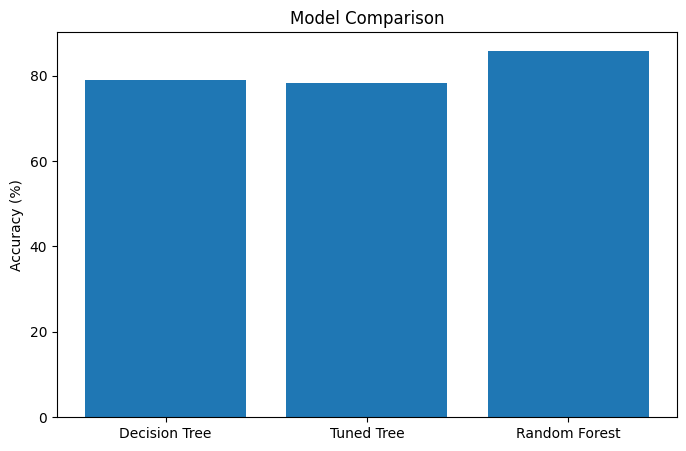

In [75]:
models = [
    "Decision Tree",
    "Tuned Tree",
    "Random Forest"
]

accuracy = [
    79.03,
    78.27,
    85.88
]

plt.figure(figsize=(8,5))

plt.bar(models, accuracy)

plt.ylabel("Accuracy (%)")

plt.title("Model Comparison")

plt.show()

In [76]:
comparison = pd.DataFrame({
    "Model": [
        "Decision Tree",
        "Tuned Decision Tree",
        "Random Forest"
    ],
    "Validation Accuracy": [
        accuracy_score(y_valid, tree_clf.predict(X_valid)),
        accuracy_score(y_valid, best_tree.predict(X_valid)),
        accuracy_score(y_valid, rf.predict(X_valid))
    ],
    "5-Fold CV Accuracy": [
        default_cv.mean(),
        tuned_cv.mean(),
        rf_cv.mean()
    ]
})

comparison

,Model,Validation Accuracy,5-Fold CV Accuracy
0,Decision Tree,0.790344,0.772652
1,Tuned Decision Tree,0.782738,0.778358
2,Random Forest,0.858796,0.856234


#  Conclusion

In this project, we explored Decision Trees for multiclass forest cover classification.

### Key Takeaways

- Built a baseline Decision Tree classifier.
- Evaluated performance using multiple metrics.
- Investigated overfitting through tree depth analysis.
- Tuned hyperparameters using GridSearchCV.
- Interpreted feature importance.
- Compared Decision Trees with Random Forests.

While Decision Trees are simple and highly interpretable, they are prone to overfitting. Random Forests overcome many of these limitations by averaging multiple trees, resulting in significantly better generalization performance.

This project serves as a practical introduction to tree-based machine learning models and provides a strong foundation for Ensemble Learning techniques.